In [ ]:
#pip install lightgbm


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------------------------------ --- 1.3/1.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor

In [ ]:
# 1. Load dữ liệu
df = pd.read_csv('../../data/processed/training_data_final.csv', parse_dates=['Datetime'], index_col='Datetime')

In [5]:
# 2. FEATURE ENGINEERING (Lag 1)
features = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target = 'Gold'

# Tạo các cột lag1
for col in features:
    df[f'{col}_lag1'] = df[col].shift(1)

df.dropna(inplace=True)

In [6]:
# 3. CHUẨN BỊ DỮ LIỆU TRAIN/TEST
X = df[[f'{col}_lag1' for col in features]]
y = df[target]

split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [7]:
# 4. KHỞI TẠO MÔ HÌNH LightGBM
model_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)


In [8]:
# 5. TRAIN
model_lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 125
[LightGBM] [Info] Number of data points in the train set: 3685, number of used features: 4
[LightGBM] [Info] Start training from score 0.586130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
# 6. DỰ ĐOÁN
y_pred = model_lgb.predict(X_test)

In [11]:
# 7. ĐÁNH GIÁ MÔ HÌNH
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.04275828492510159
R² Score: 0.9225576359624466


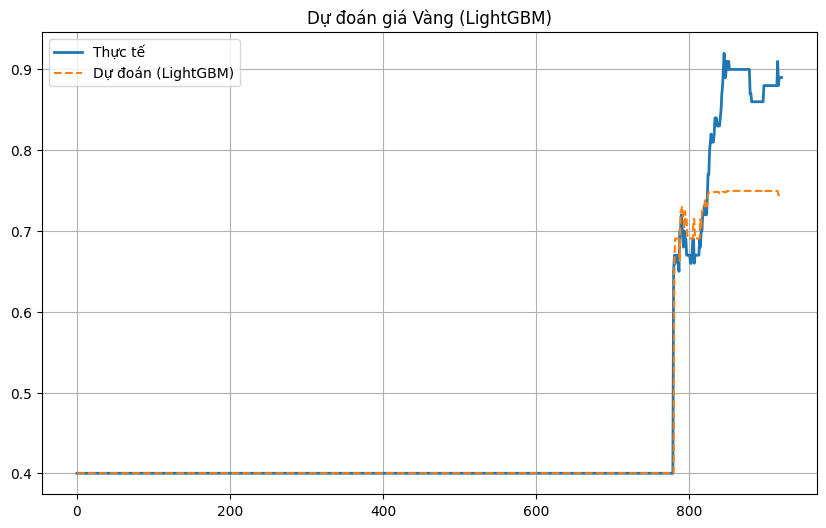

In [12]:
# 8. VẼ ĐỒ THỊ DỰ ĐOÁN
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Thực tế', linewidth=2)
plt.plot(y_pred, label='Dự đoán (LightGBM)', linestyle='--')
plt.title("Dự đoán giá Vàng (LightGBM)")
plt.legend()
plt.grid(True)
plt.show()

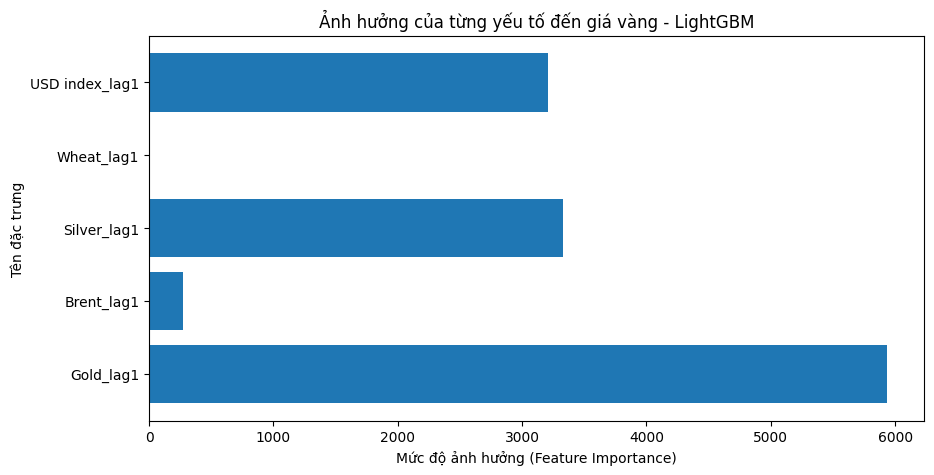

In [13]:
# 9. FEATURE IMPORTANCE
importance = model_lgb.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, importance)
plt.xlabel("Mức độ ảnh hưởng (Feature Importance)")
plt.ylabel("Tên đặc trưng")
plt.title("Ảnh hưởng của từng yếu tố đến giá vàng - LightGBM")
plt.show()